In [20]:
import importlib.util
import os
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image
from matplotlib import pyplot as plt

from pgmpy.global_vars import config
from pgmpy.inference import ApproxInference, DBNInference
from pgmpy.models import DynamicBayesianNetwork

# Whether to use GPU
USE_GPU = True

# Configure to use the GPU
if importlib.util.find_spec("torch") is not None:
    import torch

    if torch.cuda.is_available() and USE_GPU:
        print("Using torch (GPU)")
        config.set_backend("torch", device="cuda:0")
    else:
        print("Using torch (CPU)")
        config.set_backend("torch", device="cpu")
else:
    print("Using Numpy")
    config.set_backend("numpy")

# Directories
IMAGES_DIR = Path(os.getcwd()) / "images"

# Size of the random data
N_SAMPLES = 1000
N_TIME_SLICES = 2

Using torch (GPU)


# **Model**

The foundation of EMIDAS is a DBN that models a dyadic social interaction. In sociology, a dyad represents a group of two people. EMIDAS-DBN intends to observe two pedestrians being on opposite sides of the street and predicts whether they have the intention to meet the other. This intention is detected by observing social signals that provide information about whether pedestrians are interacting with each other. The EMIDAS-DBN represents the dyad by having nodes assigned to each of the pedestrians. More specifically, each variable that exists to model one of the pedestrian also exists for the second pedestrian.

The following image depicts the EMIDAS-DBN. The node coloring signalizes which nodes are assigned to the same pedestrian. The solid edges of the DBN represent instantaneous causal influences whereas the dashed edges model causal influences on the future. The nodes partitioned into three groups: feature nodes, auxiliary nodes and target nodes. The leaves of the DBN are also called feature or evidence nodes because the value of the respective variables can be observed. The target nodes in this DBN are the IMAS (intention to meet across the street) variables for each pedestrian in the dyad. We call the remaining nodes, that are neither features nor target nodes, auxiliary node.

<div align="center" style="width: 50%; margin: 0 auto">

![EMIDAS-DBN](images/emidas_dbn_model_ref.png)

</div>

**Feature nodes.** The features used to model each pedestrian are the pedestrian’s head orientation, their body orientation, their currently performed gesture and whether they are approaching the other pedestrian. Moreover, the distance between the pedestrian is used in the DBN. The features of the DBN were selected based on the categorization of non-verbal behavior in the research area of social signal processing (SSP). Hence, the features of the DBN are mostly social signals.

**Auxiliary and target nodes.** The aim of the EMIDAS-DBN is to predict whether both pedestrians in the dyad each intend to cross the street to meet the other. Since we limit ourselves to scenarios where the pedestrians interact with each other before crossing the street, we are interested in detecting ongoing social interaction. We model the feature nodes presented to far as the effect of the cause willingness to interact (WTI).

| Variables      | Values |
| ----------- | ----------- |
| Gesture (G)$^1$ | 8 different gestures and ε |
| Approaching (A) | yes, maybe, no |
| Head orientation (HO) | central, mid peripheral, outside |
| Body orientation (BO) | strongly facing, slightly facing, turned away |
| Distance (D) | discretized classes each covering 3 m |
| Willingness to interact (WTI ) | very high, high, medium, low, very low |
| Intention to meet across the street (IMAS) | very high, high, medium, low, very low |

$^1$ The **possible gestures** are: 
1. Waving with low hand level (low frequency).
2. Waving with low hand level (high frequency).
3. Waving with high hand level (low frequency).
4. Waving with high hand level (high frequency).
5. “Come here” gesture. 
6. Arm raise with low hand level.
7. Arm raise with high hand level.
8. “I’m coming” gesture.

In [21]:
# State names for each variable
FEATURE_NODES = ["G", "A", "HO", "BO", "D"]  # ["G", "A", "HO", "BO", "D"]
FEATURE_VALUES = {
    "BO": ["strongly_facing", "slightly_facing", "turned_away"],
    "G": [
        "low_wave_slow",
        "low_wave_fast",
        "high_wave_slow",
        "high_wave_fast",
        "come_here",
        "arm_raise_low",
        "arm_raise_high",
        "im_coming",
        "none",
    ],
    "A": ["yes", "maybe", "no"],
    "HO": ["central", "mid_peripheral", "outside"],
    "D": ["very_close", "close", "medium", "far", "very_far"],
    "WTI": ["very_low", "low", "medium", "high", "very_high"],
    "IMAS": ["very_low", "low", "medium", "high", "very_high"],
}

### **Algorithm**

**procedure** $\text{EMIDAS}(dbn, scene)$   
&nbsp;&nbsp;&nbsp;&nbsp;**Input:** Trained EMIDAS-DBN `dbn`, object `scene` representing a scene  
&nbsp;&nbsp;&nbsp;&nbsp;**Output:** `scene` complemented with the predicted intention to meet others across the street  
```c
    for t ← 0, scene.end do  
        for all (i, j) ∈ scene.pedLeft × scene.pedRight do  
            start ← max{0, t − dbn.slices + 2}  
            imas_i, imas_j ← UPDATEANDRETURNBELIEFS(dbn, scene.annotations(i, j, start, t))  
            scene.storePredictions(i, j, imas_i, imas_j, t)  
        end for  
    end for  
    return scene  
```
**end procedure**

```c
struct Scene
    // Pedestrians on left and right sidewalk  
    attribute pedLeft, pedRight  
    // Final time slice of the scene  
    attribute end  
    // Returns the values of all feature variables of the dyad (i, j), starting from time tₛ until tₑ  
    function annotations(i, j, tₛ, tₑ)  
    // Stores that i and j have the intentions vᵢ and vⱼ to meet the other at time t  
    function storePredictions(i, j, vᵢ, vⱼ, t)  
end struct  
```

**function** $\text{UPDATEANDRETURNBELIEFS}(dbn, E_{t':t})$   
&nbsp;&nbsp;&nbsp;&nbsp;**Input:** Trained EMIDAS-DBN `dbn`, evidence E_{t':t} of the dyad (A, B) covering the time slices t' to t     
&nbsp;&nbsp;&nbsp;&nbsp;**Output:** $\text{P}(IMAS_{t+1}^A | E_{t':t})$ and $\text{P}(IMAS_{t+1}^B | E_{t':t})$
```c
    Insert E into leaf nodes of dbn  
    dbn.updateBeliefs() // Computes the posterior probability distribution of every unobserved variable  
    return dbn.getNodeValue(IMAS_A, t + 1), dbn.getNodeValue(IMAS_B, t + 1)  
```
end function  

### **Build**

In [22]:
def build_emidas_dbn(
    feature_nodes=["G", "A", "HO", "BO", "D"], num_time_slices=2
) -> DynamicBayesianNetwork:
    """Construct the EMIDAS-DBN model using pgmpy with nodes for two pedestrians (A and B)."""
    dbn = DynamicBayesianNetwork()

    for t in range(1, num_time_slices + 1):
        for pedestrian in ["A", "B"]:
            dbn.add_node(f"IMAS_{pedestrian}")
            dbn.add_node(f"WTI_{pedestrian}")
            for node in feature_nodes:
                if t > 0:
                    # Feature node D is shared between pedestrians
                    if node != "D":
                        dbn.add_node(f"{node}_{pedestrian}")
                        dbn.add_edge(
                            (f"{node}_{pedestrian}", t - 1), (f"{node}_{pedestrian}", t)
                        )
                    else:
                        dbn.add_node(node)
                        dbn.add_edge((node, t - 1), (node, t))

            if t > 0:
                dbn.add_edge((f"IMAS_{pedestrian}", t - 1), (f"IMAS_{pedestrian}", t))
                dbn.add_edge((f"WTI_{pedestrian}", t - 1), (f"WTI_{pedestrian}", t))

        if t > 0:
            dbn.add_edge(("IMAS_A", t), ("WTI_B", t))
            dbn.add_edge(("IMAS_B", t), ("WTI_A", t))

    for pedestrian in ["A", "B"]:
        dbn.add_edge((f"IMAS_{pedestrian}", 0), (f"WTI_{pedestrian}", 0))

        for node in feature_nodes:
            if node != "D":
                dbn.add_edge((f"WTI_{pedestrian}", 0), (f"{node}_{pedestrian}", 0))
            else:
                dbn.add_edge((f"WTI_{pedestrian}", 0), (node, 0))

    return dbn

In [23]:
emidas_dbn = build_emidas_dbn(feature_nodes=FEATURE_NODES)

# **With Random Data**

In [24]:
def generate_emidas_data(
    num_samples=1000,
    num_time_slices=3,
    feature_values=FEATURE_VALUES,
    feature_nodes=FEATURE_NODES,
    default_prob_rules: dict[tuple[str | None, ...], float] | None = None,
) -> pd.DataFrame:
    """
    Generate synthetic data for the EMIDAS-DBN model with probabilistic rules.

    Parameters
    ----------
    - num_samples: Number of samples.
    - num_time_slices: Number of time steps per sample.
    - feature_nodes: List of feature nodes to include in the dataset.
    - default_prob_rules: Dictionary containing probabilistic dependencies.

    Returns
    -------
    pd.DataFrame: Synthetic dataset.
    """

    def get_probability_list(
        weights=[3, 2, 1], p=0.1, split=1, reverse=False
    ) -> list[float]:
        """Split the probability `p` into `split` parts and distribute `1 - p` according to the weights. The final
        length of the probability list will be `len(weights) + split`. The probability list will be reversed if
        `reverse` is True.

        For example,
        ```
        >>> get_probability_list(weights=[3, 2, 1], p=0.8, split_count=1, reverse=False)
        [0.33, 0.067, 0.1, 0.8]
        >>> get_probability_list(weights=[3, 2, 1], p=0.8, split_count=1, reverse=True)
        [0.8, 0.1, 0.067, 0.33]
        >>> get_probability_list(weights=[3, 2, 1], p=0.6, split_count=2, reverse=True))
        [0.3, 0.3, 0.2, 0.133, 0.067]
        >>> get_probability_list(weights=[3, 2, 1], p=0.5, split_count=2, reverse=True))
        [0.25, 0.25, 0.25, 0.167, 0.083]
        >>> get_probability_list(weights=[3, 7, 8], p=0.1, split_count=2, reverse=True)
        [0.05, 0.05, 0.15, 0.35, 0.4]
        ```
        """
        total_weight = sum(weights)

        # Distribute (1 - p) proportionally to the weights
        first_part = [(w / total_weight) * (1 - p) for w in weights][::-1]

        # Split p into `split_count` equal parts
        split_parts = [p / split] * split

        # Reverse the split parts if requested
        probability_list = first_part + split_parts
        if reverse:
            probability_list = probability_list[::-1]

        return probability_list

    if default_prob_rules is None:
        # Probabilistic rules to make WTI more likely based on feature nodes
        default_prob_rules = {
            ("BO", "strongly_facing", "G", "come_here"): 0.95,
            ("D", "very_close", "HO", "central"): 0.9,
            ("D", "close", "HO", "central"): 0.8,
            ("A", "yes", None, None): 0.8,
        }

    # Build the probabilistic rules for both pedestrians
    prob_rules = {}
    for pedestrian in ["A", "B"]:
        for rule, p in default_prob_rules.items():
            feature_node_1, v1, feature_node_2, v2 = rule
            for pedestrian in ["A", "B"]:
                prob_rules[
                    (
                        f"{feature_node_1}_{pedestrian}",
                        v1,
                        f"{feature_node_2}_{pedestrian}" if feature_node_2 else None,
                        v2,
                    )
                ] = p

    data = []
    for _ in range(num_samples):
        sample = {}

        for t in range(0, num_time_slices + 1):
            for pedestrian in ["A", "B"]:
                sample[(f"IMAS_{pedestrian}", t)] = np.random.choice(
                    feature_values["IMAS"]
                )
                sample[(f"WTI_{pedestrian}", t)] = np.random.choice(
                    feature_values["WTI"]
                )

                for node in feature_nodes:
                    if node != "D":
                        sample[(f"{node}_{pedestrian}", t)] = np.random.choice(
                            feature_values[node]
                        )
                    else:
                        sample[(node, t)] = np.random.choice(feature_values[node])

                for (n1, v1, n2, v2), p in prob_rules.items():
                    if (n1, t) in sample and (n2 is None or (n2, t) in sample):
                        if sample[(n1, t)] == v1 and (
                            v2 is None or sample[(n2, t)] == v2
                        ):
                            # WTI is more likely to be high or very high
                            # For example, a p=0.8 gives [0.099, 0.066, 0.033, 0.4, 0.4]
                            #              a p=0.6 gives [0.2, 0.133, 0.066, 0.3, 0.3]
                            # These are corresponding probs for: ["very_low", "low", "medium", "high", "very_high"]
                            # Define weights for the first three items (must decrease)
                            p = get_probability_list(
                                weights=[3, 2, 1], p=p, split=2, reverse=False
                            )
                            sample[(f"WTI_{pedestrian}", t)] = np.random.choice(
                                feature_values["WTI"], p=p
                            )

                if (f"WTI_{pedestrian}", t) in sample:
                    # Get a probability list that sums up to 1, e.g., [0.05, 0.05, 0.15, 0.35, 0.4]
                    p = get_probability_list(
                        weights=[3, 7, 8], p=0.1, split=2, reverse=True
                    )

                    # Add a rule so that if WTI is high or very high, IMAS is more likely to be high or very high
                    # p corresponds to probabilities of ["very_low", "low", "medium", "high", "very_high"]
                    if sample[(f"WTI_{pedestrian}", t)] in ["high", "very_high"]:
                        sample[(f"IMAS_{pedestrian}", t)] = np.random.choice(
                            feature_values["IMAS"], p=p
                        )
                    else:
                        # If WTI is not high or very high, IMAS is more likely to be low or very low
                        sample[(f"IMAS_{pedestrian}", t)] = np.random.choice(
                            feature_values["IMAS"], p=p[::-1]
                        )

        data.append(sample)

    return pd.DataFrame(data, dtype="<U22")

In [25]:
# Generate Training Data
data = generate_emidas_data(N_SAMPLES, N_TIME_SLICES)
data

,"(IMAS_A, 0)","(WTI_A, 0)","(G_A, 0)","(A_A, 0)","(HO_A, 0)","(BO_A, 0)","(D, 0)","(IMAS_B, 0)","(WTI_B, 0)","(G_B, 0)",...,"(A_A, 2)","(HO_A, 2)","(BO_A, 2)","(D, 2)","(IMAS_B, 2)","(WTI_B, 2)","(G_B, 2)","(A_B, 2)","(HO_B, 2)","(BO_B, 2)"
0,very_low,low,high_wave_slow,no,central,turned_away,far,low,very_low,none,...,no,mid_peripheral,strongly_facing,very_close,very_high,low,come_here,yes,outside,turned_away
1,very_low,very_high,arm_raise_low,yes,central,strongly_facing,far,very_low,low,high_wave_fast,...,maybe,outside,turned_away,medium,very_low,low,low_wave_slow,maybe,central,strongly_facing
2,low,low,arm_raise_high,yes,central,slightly_facing,close,high,very_high,none,...,maybe,central,strongly_facing,far,low,very_high,low_wave_fast,no,mid_peripheral,slightly_facing
3,very_low,high,come_here,yes,mid_peripheral,strongly_facing,medium,medium,very_high,none,...,yes,mid_peripheral,turned_away,very_close,very_high,very_high,im_coming,no,outside,slightly_facing
4,high,high,arm_raise_high,yes,mid_peripheral,slightly_facing,very_far,medium,medium,im_coming,...,no,mid_peripheral,slightly_facing,very_close,high,high,low_wave_fast,no,mid_peripheral,turned_away
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,low,very_low,high_wave_fast,maybe,mid_peripheral,slightly_facing,very_close,very_low,medium,come_here,...,maybe,outside,strongly_facing,very_close,medium,very_high,come_here,yes,outside,turned_away
996,medium,high,im_coming,maybe,central,slightly_facing,very_far,very_low,low,low_wave_fast,...,yes,mid_peripheral,slightly_facing,medium,very_high,high,high_wave_slow,yes,outside,strongly_facing
997,very_low,low,high_wave_fast,maybe,mid_peripheral,turned_away,medium,medium,very_high,come_here,...,yes,mid_peripheral,strongly_facing,far,very_high,very_high,none,maybe,outside,slightly_facing
998,very_high,very_high,arm_raise_low,no,central,strongly_facing,far,low,medium,none,...,no,outside,turned_away,far,very_low,low,low_wave_fast,no,central,slightly_facing


### **Test *bias* in data priors**

In [26]:
data[(data[("BO_A", 0)] == "strongly_facing") & (data[("G_A", 0)] == "come_here")][("WTI_A", 0)].value_counts(normalize=True)

(WTI_A, 0)
high         0.510638
very_high    0.404255
very_low     0.042553
medium       0.042553
Name: proportion, dtype: float64

In [27]:
data[(data[("D", 0)] == "close") & (data[("HO_A", 0)] == "central")][("WTI_A", 0)].value_counts(normalize=True)

(WTI_A, 0)
very_high    0.266667
very_low     0.213333
high         0.186667
low          0.173333
medium       0.160000
Name: proportion, dtype: float64

In [28]:
data[(data[("A_A", 0)] == "yes")][("WTI_A", 0)].value_counts(normalize=True)

(WTI_A, 0)
high         0.417647
very_high    0.385294
low          0.097059
medium       0.061765
very_low     0.038235
Name: proportion, dtype: float64

### **Preprocessing**

In [29]:
# Label encode the data per feature column
data_encoded = data.copy()
for node in data.columns:
    feature_name = node[0].split("_")[0]
    data_encoded[node] = data[node].apply(lambda x: FEATURE_VALUES[feature_name].index(x))

data_encoded

,"(IMAS_A, 0)","(WTI_A, 0)","(G_A, 0)","(A_A, 0)","(HO_A, 0)","(BO_A, 0)","(D, 0)","(IMAS_B, 0)","(WTI_B, 0)","(G_B, 0)",...,"(A_A, 2)","(HO_A, 2)","(BO_A, 2)","(D, 2)","(IMAS_B, 2)","(WTI_B, 2)","(G_B, 2)","(A_B, 2)","(HO_B, 2)","(BO_B, 2)"
0,0,1,2,2,0,2,3,1,0,8,...,2,1,0,0,4,1,4,0,2,2
1,0,4,5,0,0,0,3,0,1,3,...,1,2,2,2,0,1,0,1,0,0
2,1,1,6,0,0,1,1,3,4,8,...,1,0,0,3,1,4,1,2,1,1
3,0,3,4,0,1,0,2,2,4,8,...,0,1,2,0,4,4,7,2,2,1
4,3,3,6,0,1,1,4,2,2,7,...,2,1,1,0,3,3,1,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,0,3,1,1,1,0,0,2,4,...,1,2,0,0,2,4,4,0,2,2
996,2,3,7,1,0,1,4,0,1,1,...,0,1,1,2,4,3,2,0,2,0
997,0,1,3,1,1,2,2,2,4,4,...,0,1,0,3,4,4,8,1,2,1
998,4,4,5,2,0,0,3,1,2,8,...,2,2,2,3,0,1,1,2,0,1


## **Training**

In [30]:
emidas_dbn.fit(data)
emidas_dbn.check_model()

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'BO_A_0': 'C', 'A_A_0': 'C', 'IMAS_A_0': 'C', 'G_B_0': 'C', 'WTI_B_0': 'C', 'BO_B_0': 'C', 'WTI_A_0': 'C', 'A_B_0': 'C', 'G_A_0': 'C', 'IMAS_B_0': 'C', 'D_0': 'C', 'HO_A_0': 'C', 'HO_B_0': 'C', 'BO_A_1': 'C', 'A_A_1': 'C', 'IMAS_A_1': 'C', 'G_B_1': 'C', 'WTI_B_1': 'C', 'BO_B_1': 'C', 'WTI_A_1': 'C', 'A_B_1': 'C', 'G_A_1': 'C', 'IMAS_B_1': 'C', 'D_1': 'C', 'HO_A_1': 'C', 'HO_B_1': 'C'}


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'BO_A_0': 'C', 'A_A_0': 'C', 'IMAS_A_0': 'C', 'G_B_0': 'C', 'WTI_B_0': 'C', 'BO_B_0': 'C', 'WTI_A_0': 'C', 'A_B_0': 'C', 'G_A_0': 'C', 'IMAS_B_0': 'C', 'D_0': 'C', 'HO_A_0': 'C', 'HO_B_0': 'C', 'BO_A_1': 'C', 'A_A_1': 'C', 'IMAS_A_1': 'C', 'G_B_1': 'C', 'WTI_B_1': 'C', 'BO_B_1': 'C', 'WTI_A_1': 'C', 'A_B_1': 'C', 'G_A_1': 'C', 'IMAS_B_1': 'C', 'D_1': 'C', 'HO_A_1': 'C', 'HO_B_1': 'C'}


True

## **Inference**

In [31]:
# Get CPDs
print(emidas_dbn.get_cpds(("IMAS_A", 1)))

+------------------------+-----+-----------------------+
| (IMAS_A, 0)            | ... | (IMAS_A, 0)(very_low) |
+------------------------+-----+-----------------------+
| (IMAS_A, 1)(high)      | ... | 0.19840222735737645   |
+------------------------+-----+-----------------------+
| (IMAS_A, 1)(low)       | ... | 0.15916875034471684   |
+------------------------+-----+-----------------------+
| (IMAS_A, 1)(medium)    | ... | 0.15003253772013211   |
+------------------------+-----+-----------------------+
| (IMAS_A, 1)(very_high) | ... | 0.2752080771614151    |
+------------------------+-----+-----------------------+
| (IMAS_A, 1)(very_low)  | ... | 0.21718840741635953   |
+------------------------+-----+-----------------------+


In [32]:
# Question: P(IMAS_A[9] = very high | HOA[0:8] = central, BOA[0:8] = strongly facing
# evidence = {
#     ("HO_A", 0): FEATURE_VALUES["HO"].index("central"),
#     ("BO_A", 0): FEATURE_VALUES["BO"].index("slightly_facing"),
#     ("HO_A", 1): FEATURE_VALUES["HO"].index("central"),
#     ("BO_A", 1): FEATURE_VALUES["BO"].index("strongly_facing"),
# }

evidence = {
    ("HO_A", 0): "central",
}

print(evidence)

# Perform query using Approximate Inference
dbn_approx_inference = ApproxInference(emidas_dbn)
samples = dbn_approx_inference.query(
    variables=[("IMAS_A", 9)],
    evidence=evidence,
    n_samples=10,
)

print(samples)

{('HO_A', 0): 'central'}


  0%|          | 0/130 [00:00<?, ?it/s]

TypeError: The axis argument to unique is not supported for dtype object

In [14]:
# # This takes a long time
# evidence = {
#     ("HO_A", 0): FEATURE_VALUES["HO"].index("central"),
#     ("BO_A", 0): FEATURE_VALUES["BO"].index("slightly_facing"),
#     ("HO_A", 1): FEATURE_VALUES["HO"].index("central"),
#     ("BO_A", 1): FEATURE_VALUES["BO"].index("strongly_facing"),
# }

# dbn_inference = DBNInference(emidas_dbn)

# print(f"Probabilities for {("IMAS_A", 3)} given evidence:")
# print(dbn_inference.backward_inference([("IMAS_A", 2)], evidence=evidence))

In [15]:
del data

In the second example, we are again interested in an explanation for the DBN's prediction. Compared to the first example, we change the feature node set to M = {HOA[t], GA[t] | Vt ∈ {0,...8}}.

**Question:** How likely is the prediction that A has a very strong intention to meet B in the next time step when B was in the central field of view of A and A was widely waving at B in the past nine time steps? (GBF = 6.74)

**Answer:** $P(IMAS_A[9] = very \, high \, | \, HOA[0:8] = central, \, GA[0:8] = WaveWideHead) = 69.08\%$

In the third example, we are interested in using the inference method filtering and select the feature node set M = {HOA[t], AA[t], HOB[t] | Vt ∈ {0,...8}}.

**Question:** How likely is the prediction that A has a very strong intention to meet B now when B is in the central field of view of A for the past second, A is approaching B for the past second and A is in the mid peripheral area of B for the past four time steps? (GBF = 7.51)

**Answer:** $P(IMAS_A[9] = very \, high \, | \, HOA[0:9] = central, AA[0:9] = y, HOA[6:9] = mid \, peripheral) = 77.05\%$

# **With Original Data**

In [16]:
import importlib.util
import os
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image
from matplotlib import pyplot as plt
from sklearn.calibration import LabelEncoder
from utils import colors, misc

from pgmpy.factors.discrete import TabularCPD
from pgmpy.global_vars import config
from pgmpy.inference import ApproxInference, DBNInference
from pgmpy.models import DynamicBayesianNetwork

# Configure to use the GPU
if importlib.util.find_spec("torch") is not None:
    import torch

    if torch.cuda.is_available():
        print("Using torch (GPU)")
        config.set_backend("torch", device="cuda:0")
    else:
        print("Using torch (CPU)")
        config.set_backend("torch", device="cpu")
else:
    print("Using Numpy")
    config.set_backend("numpy")

# Directories
IMAGES_DIR = Path(os.getcwd()) / "images"
DATA_DIR = Path(os.getcwd()) / "data"
LOAD_FROM_DATA_DIR = ["01", "02", "03"] #, "04"] #, "05", "06", "08"]

ModuleNotFoundError: No module named 'utils'

In [ ]:
# Load the csv files and concatenate them all
data = None
for folder in LOAD_FROM_DATA_DIR:
    if (DATA_DIR / folder).exists():
        print(f"Loading data from {DATA_DIR / folder}... ", end="")
        df = pd.read_csv(DATA_DIR / folder / "training_data.csv")
        data = pd.concat([data, df], ignore_index=True).reset_index(drop=True) if data is not None else df
        print(f"Done (shape: {df.shape})")
        del df
    else:
        print(f"Folder {DATA_DIR / folder} does not exist.")

data.head()

In [19]:
# Should only be the "gesture" columns, and those must be filled with the string "none"
cols_with_nan = data.columns[data.isnull().any()].tolist()
for col in cols_with_nan:
    assert "gesture" in col  # Only the "gesture" columns should have missing values
    data[col] = data[col].fillna("none")

# Assert that there are no missing values
assert data.columns[data.isnull().any()].tolist() == []

In [20]:
# Columns are like: 
# 'dist', 'dist_1', ..., 'dist_9', 'p1_approach_1', 'p1_approach_2', ..., 'p1_gesture_9'
# * The first number (p1) represents the pedestrian
# * The second number represents the time slice
# * dist doesn't have the first number because it's shared between pedestrians
# So, define a mapping to make participants be A and B, and make the features be the same as in state names of the model

# Define the feature mapping
feature_mapping = {
    "dist": "D",
    "gesture": "G",
    "approach": "A",
    "head": "HO",
    "body": "BO",
    "imas": "IMAS",
    "wti": "WTI",
}

# Participant mapping
participant_mapping = {
    "p1": "A",
    "p2": "B",
}

# Perform the renaming of the columns, such that we get columns: ('IMAS_A', 0), ('WTI_A', 0), ('G_A', 0), ...
column_replacements = {}
for col in data.columns:
    if col == "dist": # First time slice
        column_replacements[col] = ("D", 0)
    elif "dist" in col: # Other time slices
        column_replacements[col] = ("D", int(col.split("_")[1]))
    else: # Other columns
        split = col.split("_")
        if len(split) == 2: # First time slice
            participant, feature = split
            column_replacements[col] = (feature_mapping[feature] + "_" + participant_mapping[participant], 0)
        else: # Other time slices
            participant, feature, t = split
            column_replacements[col] = (feature_mapping[feature] + "_" + participant_mapping[participant], int(t))
    
data.rename(columns=column_replacements, inplace=True)    

In [ ]:
data.head()

In [22]:
# Construct an equivalent of the FEATURE_VALUES dictionary for the values in each column to integers
data_encoded = data.copy()
label_encoders = {}
for col in data.columns:
    col_feature, _ = col  # ("IMAS_A", 0) -> "IMAS_A"
    label_encoder = LabelEncoder()
    data_encoded[col] = label_encoder.fit_transform(data[col])
    label_encoders[col_feature] = label_encoder

In [ ]:
for col in label_encoders:
    print(f"{col}: {label_encoders[col].classes_}")

In [ ]:
emidas_dbn = build_emidas_dbn(feature_nodes=FEATURE_NODES, num_time_slices=10)
create_visualization(emidas_dbn)
Image(IMAGES_DIR / "emidas_dbn_graphviz.png")

In [ ]:
emidas_dbn.fit(data_encoded)
emidas_dbn.check_model()

In [26]:
# # This takes a long time
# evidence = {
#     ("HO_A", 0): FEATURE_VALUES["HO"].index("central"),
#     ("BO_A", 0): FEATURE_VALUES["BO"].index("slightly_facing"),
#     ("HO_A", 1): FEATURE_VALUES["HO"].index("central"),
#     ("BO_A", 1): FEATURE_VALUES["BO"].index("strongly_facing"),
# }

# # Check that the evidence values are valid
# # for node, value in evidence.items():
# #     assert value in data[node].unique(), f"Invalid value {value} for node {node}"

# dbn_inference = DBNInference(emidas_dbn)

# print(f"Probabilities for {("IMAS_A", 3)} given evidence:")
# print(dbn_inference.backward_inference([("IMAS_A", 2)], evidence=evidence))

Given a target variable $target ∈ \{IMAS_A, IMAS_B\}$, a selected target value $v_{target} \in \{very \, high, ..., very \, low\}$ and a set of feature nodes M, we use the Most Relevant Explanation (MRE) method to select a subset of features X ⊆ M that conceive a relevant question about the evidence target = Utarget. This question is then answered using probabilistic inference (Definition 3).

The MRE method amounts to calculate $GBF(x: v_{target})$ for all possible feature subsets X and for all possible feature instances. Since we consider a DBN, the instance of each feature is a sequence of values of maximal length T, where T is the number of slices to which the DBN unrolls. We now present and discuss several examples.

In the first example, we aim to obtain a question that is answered using prediction (see Definition 3). We use a trained EMIDAS-DBN that unrolls to T = 10 slices and select the target variable and its value IMAS_A[9] = very high as well as the feature nodes M = {HOA[t], BOA[t] | Vt ∈ {0,...8}}. We perform MRE(M: IMAS_A[9] = very high) and obtain the following question which has a GBF of 4.48:

**Question:** How likely is the prediction that A has a very strong intention to meet B in the next time step when B was in the central field of view of A and A was strongly facing B in the past nine time steps? (GBF = 4.48)

**Answer:** $P(IMAS_A[9] = very \, high \, | \, HOA[0:8] = central, BOA[0:8] = strongly \, facing) = 45.93\%$

In [ ]:
# Question: P(IMAS_A[9] = very high | HOA[0:8] = central, BOA[0:8] = strongly facing
evidence = {
    ("HO_A", 0): label_encoders["HO_A"].transform(["central"])[0].item(),
    ("HO_A", 1): label_encoders["HO_A"].transform(["central"])[0].item(),
    ("HO_A", 2): label_encoders["HO_A"].transform(["central"])[0].item(),
    ("HO_A", 3): label_encoders["HO_A"].transform(["central"])[0].item(),
    ("HO_A", 4): label_encoders["HO_A"].transform(["central"])[0].item(),
    ("HO_A", 5): label_encoders["HO_A"].transform(["central"])[0].item(),
    ("HO_A", 6): label_encoders["HO_A"].transform(["central"])[0].item(),
    ("HO_A", 7): label_encoders["HO_A"].transform(["central"])[0].item(),
    ("HO_A", 8): label_encoders["HO_A"].transform(["central"])[0].item(),
    ("BO_A", 0): label_encoders["BO_A"].transform(["strongly_facing"])[0].item(),
    ("BO_A", 1): label_encoders["BO_A"].transform(["strongly_facing"])[0].item(),
    ("BO_A", 2): label_encoders["BO_A"].transform(["strongly_facing"])[0].item(),
    ("BO_A", 3): label_encoders["BO_A"].transform(["strongly_facing"])[0].item(),
    ("BO_A", 4): label_encoders["BO_A"].transform(["strongly_facing"])[0].item(),
    ("BO_A", 5): label_encoders["BO_A"].transform(["strongly_facing"])[0].item(),
    ("BO_A", 6): label_encoders["BO_A"].transform(["strongly_facing"])[0].item(),
    ("BO_A", 7): label_encoders["BO_A"].transform(["strongly_facing"])[0].item(),
    ("BO_A", 8): label_encoders["BO_A"].transform(["strongly_facing"])[0].item(),
}

print(evidence)

# Perform query using Approximate Inference
dbn_approx_inference = ApproxInference(emidas_dbn)
samples = dbn_approx_inference.query(
    variables=[("IMAS_A", 9)],
    evidence=evidence,
    n_samples=1000,
)

print(samples)
print(label_encoders["IMAS_A"].classes_.tolist())

Given that the EMIDAS-DBN unrolls to $T = 10$ time slices and given some evidence data $E[t = 0 : 8]$, the following table depicts the explanation for the prediction result $P(IMAS_A[t = 9] = \text{very high} \, | \, E[t = 0 : 8]) = 0.9272$ by means of an evidence balance sheet:

<div align="center" style="width: 50%; margin: 0 auto">

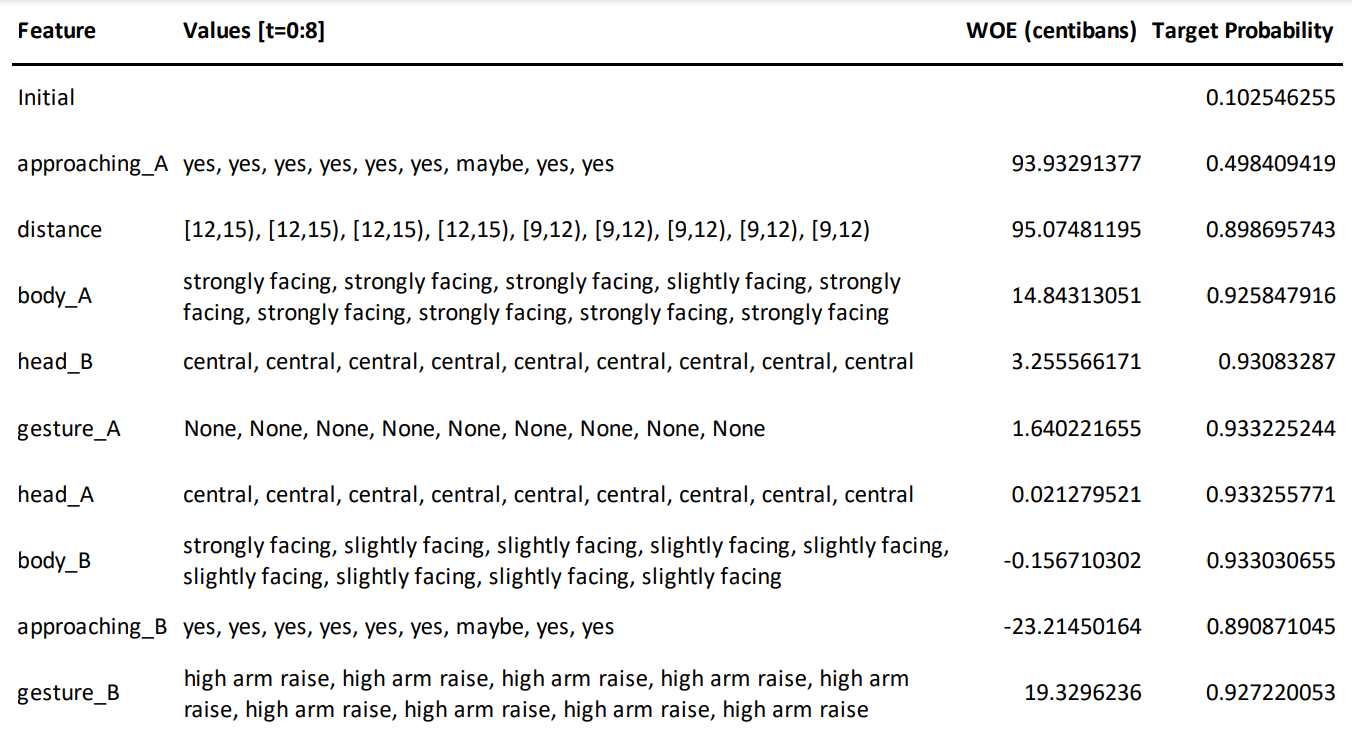

</div>

In [ ]:
evidence = {
    ("A_A", 0): label_encoders["A_A"].transform(["y"])[0].item(),
    ("A_A", 1): label_encoders["A_A"].transform(["y"])[0].item(),
    ("A_A", 2): label_encoders["A_A"].transform(["y"])[0].item(),
    ("A_A", 3): label_encoders["A_A"].transform(["y"])[0].item(),
    ("A_A", 4): label_encoders["A_A"].transform(["y"])[0].item(),
    ("A_A", 5): label_encoders["A_A"].transform(["y"])[0].item(),
    ("A_A", 6): label_encoders["A_A"].transform(["m"])[0].item(),
    ("A_A", 7): label_encoders["A_A"].transform(["y"])[0].item(),
    ("A_A", 8): label_encoders["A_A"].transform(["y"])[0].item(),

    ("D", 0): label_encoders["D"].transform(["range_12_15"])[0].item(),
    ("D", 1): label_encoders["D"].transform(["range_12_15"])[0].item(),
    ("D", 2): label_encoders["D"].transform(["range_12_15"])[0].item(),
    ("D", 3): label_encoders["D"].transform(["range_12_15"])[0].item(),
    ("D", 4): label_encoders["D"].transform(["range_9_12"])[0].item(),
    ("D", 5): label_encoders["D"].transform(["range_9_12"])[0].item(),
    ("D", 6): label_encoders["D"].transform(["range_9_12"])[0].item(),
    ("D", 7): label_encoders["D"].transform(["range_9_12"])[0].item(),
    ("D", 8): label_encoders["D"].transform(["range_9_12"])[0].item(),

    ("BO_A", 0): label_encoders["BO_A"].transform(["strongly_facing"])[0].item(),
    ("BO_A", 1): label_encoders["BO_A"].transform(["strongly_facing"])[0].item(),
    ("BO_A", 2): label_encoders["BO_A"].transform(["strongly_facing"])[0].item(),
    ("BO_A", 3): label_encoders["BO_A"].transform(["slightly_facing"])[0].item(),
    ("BO_A", 4): label_encoders["BO_A"].transform(["strongly_facing"])[0].item(),
    ("BO_A", 5): label_encoders["BO_A"].transform(["strongly_facing"])[0].item(),
    ("BO_A", 6): label_encoders["BO_A"].transform(["strongly_facing"])[0].item(),
    ("BO_A", 7): label_encoders["BO_A"].transform(["strongly_facing"])[0].item(),
    ("BO_A", 8): label_encoders["BO_A"].transform(["strongly_facing"])[0].item(),

    ("HO_B", 0): label_encoders["HO_B"].transform(["central"])[0].item(),
    ("HO_B", 1): label_encoders["HO_B"].transform(["central"])[0].item(),
    ("HO_B", 2): label_encoders["HO_B"].transform(["central"])[0].item(),
    ("HO_B", 3): label_encoders["HO_B"].transform(["central"])[0].item(),
    ("HO_B", 4): label_encoders["HO_B"].transform(["central"])[0].item(),
    ("HO_B", 5): label_encoders["HO_B"].transform(["central"])[0].item(),
    ("HO_B", 6): label_encoders["HO_B"].transform(["central"])[0].item(),
    ("HO_B", 7): label_encoders["HO_B"].transform(["central"])[0].item(),
    ("HO_B", 8): label_encoders["HO_B"].transform(["central"])[0].item(),

    ("G_A", 0): label_encoders["G_A"].transform(["none"])[0].item(),
    ("G_A", 1): label_encoders["G_A"].transform(["none"])[0].item(),
    ("G_A", 2): label_encoders["G_A"].transform(["none"])[0].item(),
    ("G_A", 3): label_encoders["G_A"].transform(["none"])[0].item(),
    ("G_A", 4): label_encoders["G_A"].transform(["none"])[0].item(),
    ("G_A", 5): label_encoders["G_A"].transform(["none"])[0].item(),
    ("G_A", 6): label_encoders["G_A"].transform(["none"])[0].item(),
    ("G_A", 7): label_encoders["G_A"].transform(["none"])[0].item(),
    ("G_A", 8): label_encoders["G_A"].transform(["none"])[0].item(),

    ("HO_A", 0): label_encoders["HO_A"].transform(["central"])[0].item(),
    ("HO_A", 1): label_encoders["HO_A"].transform(["central"])[0].item(),
    ("HO_A", 2): label_encoders["HO_A"].transform(["central"])[0].item(),
    ("HO_A", 3): label_encoders["HO_A"].transform(["central"])[0].item(),
    ("HO_A", 4): label_encoders["HO_A"].transform(["central"])[0].item(),
    ("HO_A", 5): label_encoders["HO_A"].transform(["central"])[0].item(),
    ("HO_A", 6): label_encoders["HO_A"].transform(["central"])[0].item(),
    ("HO_A", 7): label_encoders["HO_A"].transform(["central"])[0].item(),
    ("HO_A", 8): label_encoders["HO_A"].transform(["central"])[0].item(),
}

dbn_approx_inference = ApproxInference(emidas_dbn)
samples = dbn_approx_inference.query(
    variables=[("IMAS_A", 9)],
    evidence=evidence,
    n_samples=1000,
)

print(samples)
print(label_encoders["IMAS_A"].classes_.tolist())

# **To Check**

In [ ]:
from pgmpy.sampling import GibbsSampling

gibbs_sampler = GibbsSampling(emidas_dbn)

# Generate samples using Gibbs Sampling
gibbs_samples = gibbs_sampler.sample(size=1000, include_latents=True)
print(gibbs_samples)

# Compute probability of IMAS_B at time 3
probability_gibbs = gibbs_samples["IMAS_B", 3].value_counts(normalize=True)
print(probability_gibbs)

In [124]:
# This takes a long time
# evidence = {
#     ("HO_A", 0): FEATURE_VALUES["HO"].index("central"),
#     ("BO_A", 0): FEATURE_VALUES["BO"].index("slightly_facing"),
#     ("HO_A", 1): FEATURE_VALUES["HO"].index("central"),
#     ("BO_A", 1): FEATURE_VALUES["BO"].index("strongly_facing"),
# }

# # Check that the evidence values are valid
# # for node, value in evidence.items():
# #     assert value in data[node].unique(), f"Invalid value {value} for node {node}"

# dbn_inference = DBNInference(emidas_dbn)

# print(f"Probabilities for {("IMAS_A", 3)} given evidence:")
# print(dbn_inference.backward_inference([("IMAS_A", 2)], evidence=evidence))